# SmartCare Hospital AI - Disease Risk Classification (Option C)
**Coursework Code:** CCS3440 – Artificial Intelligence  
**Target Variable:** `disease_risk_level` (Multi-Class Classification: Low, Medium, High)  

This notebook covers Tasks 02 to 07 for the selected prediction problem. The target is explicitly the disease risk level, and the remaining patient variables are treated as input features after excluding identifiers and known leakage variables.

---


## Task 02: Dataset Understanding

This stage checks the dataset structure, the prediction target, relevant attribute groups, and data quality issues before the model workflow begins.


### 2.1 Load Dataset and Libraries

The dataset and the supporting data dictionary are loaded first so the attribute meanings can be checked before any modelling step.


In [25]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path("..")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
MODELS_DIR = PROJECT_ROOT / "models"

for p in [PROCESSED_DATA_DIR, FIGURES_DIR, METRICS_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

data_path = RAW_DATA_DIR / "smartcare_ai_dataset_1000.csv"
dict_path = RAW_DATA_DIR / "smartcare_ai_dataset_data_dictionary.csv"

assert data_path.exists(), f"Raw data file not found: {data_path}"
assert dict_path.exists(), f"Data dictionary file not found: {dict_path}"

df = pd.read_csv(data_path)
df_dict = pd.read_csv(dict_path)

print(f"Dataset Shape: {df.shape}")
display(df.head())


Dataset Shape: (1000, 33)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


### 2.2 Inspect Data Types & Quality Assessment

The dataset contains 1,000 patient records from several healthcare groups. The target variable is `disease_risk_level`, and the other columns are analysed as candidate predictors after excluding unsuitable variables.


In [26]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   str    
 2   age                           1000 non-null   int64  
 3   gender                        1000 non-null   str    
 4   blood_group                   1000 non-null   str    
 5   department                    1000 non-null   str    
 6   diagnosis                     1000 non-null   str    
 7   appointment_date              1000 non-null   str    
 8   waiting_days                  1000 non-null   int64  
 9   previous_appointments         1000 non-null   int64  
 10  missed_previous_appointments  1000 non-null   int64  
 11  appointment_status            1000 non-null   str    
 12  admitted                      1000 non-null   int64  
 13  room_type      

In [27]:
display(df_dict)


,Column,Description
0,record_id,Unique row identifier
1,patient_id,Synthetic patient identifier
2,age,Patient age in years
3,gender,Patient gender
4,blood_group,Patient blood group
5,department,Hospital department
6,diagnosis,Primary diagnosis category
7,appointment_date,Appointment date
8,waiting_days,Number of days between booking and appointment
9,previous_appointments,Number of previous appointments


## Task 03: Data Preprocessing & Feature Engineering

The main preparation steps here are missing-value handling, duplicate checking, outlier review, engineered feature creation, and safe splitting before model training.


### 3.1 Check Missing Values & Duplicate Records

The missing-value analysis shows that `room_type` is the main incomplete field, while the duplicate count is zero. This means the data is largely clean, but the room assignment field needs a meaningful handling strategy because it is part of the data dictionary and not just a random missing value.


In [28]:
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
print("Missing values per feature:")
display(missing_summary)

duplicates = df.duplicated().sum()
print(f"Duplicate records: {duplicates}")


Missing values per feature:


room_type    906
dtype: int64

Duplicate records: 0


### 3.2 Handling Outliers and Missing Value Imputation

A new copy of the dataset is kept for preprocessing. Missing room assignments are converted to `None`, which matches the dataset dictionary, while numeric missing values are handled later in the sklearn pipeline to avoid leakage from the full dataset.


In [29]:
data = df.copy()
data["room_type"] = data["room_type"].fillna("None")
print("Prepared data rows:", data.shape[0])
print(data["room_type"].value_counts(dropna=False).head())


Prepared data rows: 1000
room_type
None            906
General Ward     52
Private Room     33
ICU               9
Name: count, dtype: int64


### 3.3 Feature Engineering

The engineered features are created from the existing hospital cost and treatment variables. They summarise payment burden and care intensity in a way that is consistent with the original dataset and does not invent new clinical information.


In [30]:
financial_cols = [
    "consultation_fee_lkr",
    "lab_charge_lkr",
    "room_charge_lkr",
    "medicine_charge_lkr",
]

if all(col in data.columns for col in financial_cols):
    data["calculated_total_bill"] = (
        data["consultation_fee_lkr"].fillna(0)
        + data["lab_charge_lkr"].fillna(0)
        + data["room_charge_lkr"].fillna(0)
        + data["medicine_charge_lkr"].fillna(0)
    )

    if "total_bill_lkr" in data.columns:
        diff_median = (data["calculated_total_bill"] - data["total_bill_lkr"]).abs().median()
        print("Median absolute difference between calculated and reported total bill:", diff_median)
else:
    print("Required financial columns are not available.")

care_cols = [
    "lab_tests_count",
    "treatments_count",
    "length_of_stay_days",
]

if all(col in data.columns for col in care_cols):
    data["stay_duration"] = data["length_of_stay_days"].fillna(1).clip(lower=1)
    data["care_intensity_index"] = (
        data["lab_tests_count"].fillna(0)
        + data["treatments_count"].fillna(0)
    ) / data["stay_duration"]
    print("Care intensity index created.")
else:
    print("Required care intensity columns are not available.")

engineered_cols = [
    col for col in ["calculated_total_bill", "stay_duration", "care_intensity_index"]
    if col in data.columns
]

display(data[engineered_cols].head())


Median absolute difference between calculated and reported total bill: 0.0
Care intensity index created.


,calculated_total_bill,stay_duration,care_intensity_index
0,13596,1,3.0
1,5652,1,1.0
2,6262,1,1.0
3,17262,1,3.0
4,20414,1,2.0


### 3.4 Target Encoding & Export Processed Data

The target distribution is inspected before modelling. The target is not encoded manually during exploration because the label encoder is handled safely within the model pipeline and training split.


In [31]:
if "disease_risk_level" in data.columns:
    print("Target value counts:")
    display(data["disease_risk_level"].value_counts())
else:
    print("Target column not found in data")


Target value counts:


disease_risk_level
Medium    469
High      400
Low       131
Name: count, dtype: int64

## Task 04: Exploratory Data Analysis (EDA)

This section reviews the class balance, the spread of important clinical variables, and the relationships between patient features and the risk levels.


### 4.1 Target Variable Distribution

The target is not perfectly balanced. Medium-risk patients form the largest group, followed by High-risk and then Low-risk patients. This imbalance matters, so macro metrics are used alongside accuracy when selecting the best model.


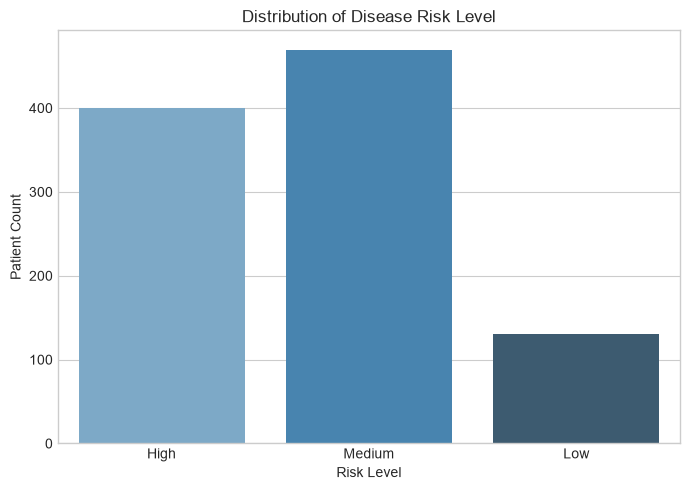

Class counts:
 disease_risk_level
Medium    469
High      400
Low       131
Name: count, dtype: int64
Class percentages (%):
 disease_risk_level
Medium    46.9
High      40.0
Low       13.1
Name: proportion, dtype: float64


In [33]:
plt.figure(figsize=(7, 5))
sns.countplot(data=data, x="disease_risk_level", palette="Blues_d")
plt.title("Distribution of Disease Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Patient Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=300)
plt.show()

vc = data["disease_risk_level"].value_counts()
vp = data["disease_risk_level"].value_counts(normalize=True) * 100
print("Class counts:\n", vc)
print("Class percentages (%):\n", vp.round(2))


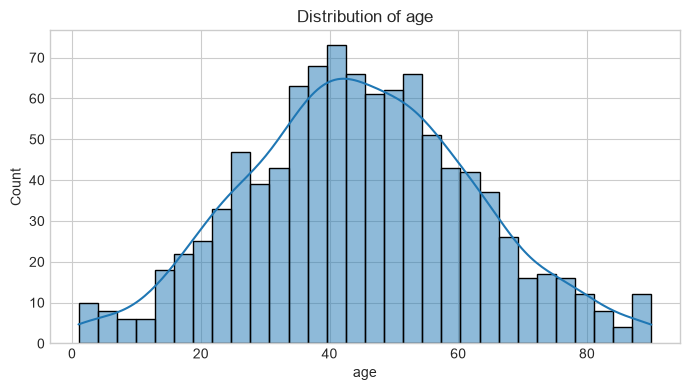

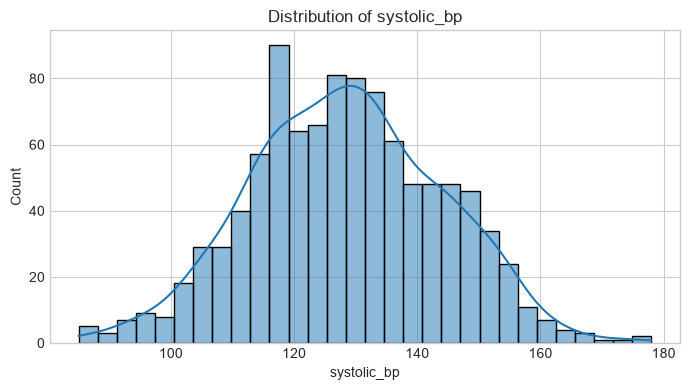

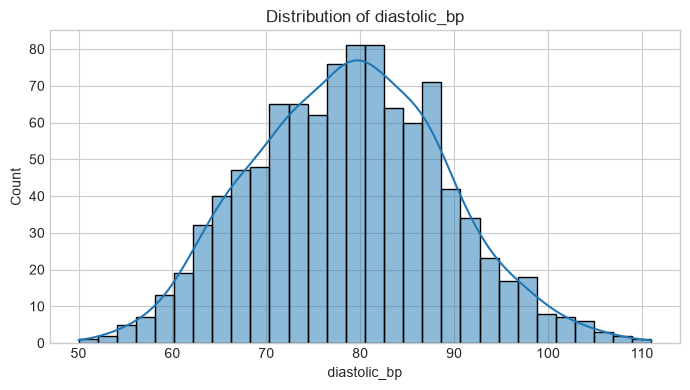

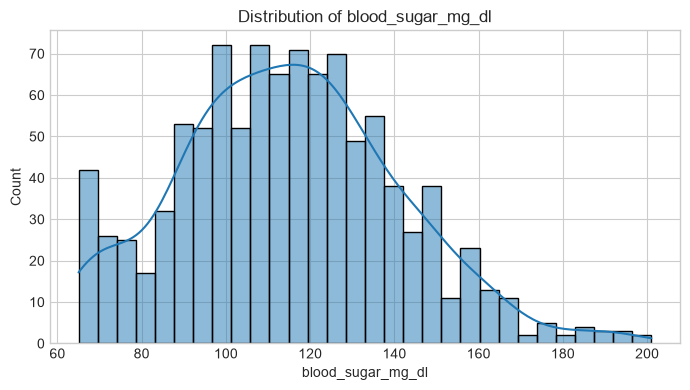

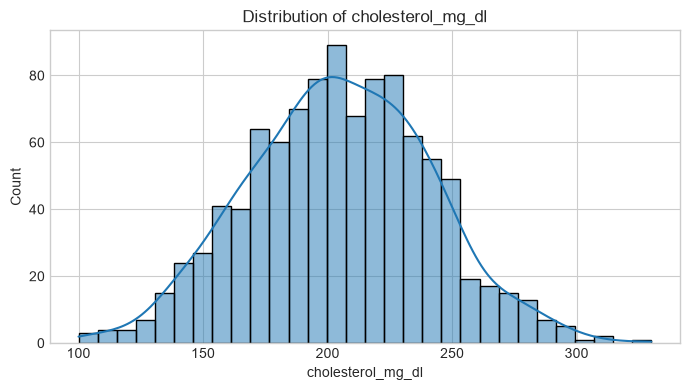

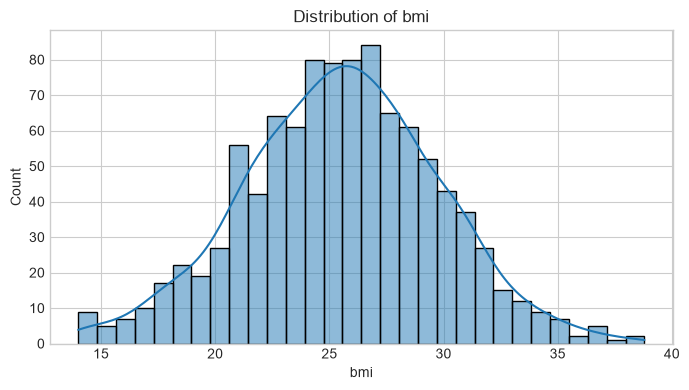

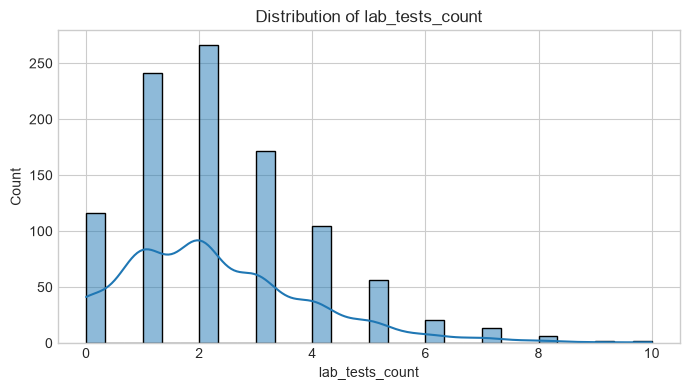

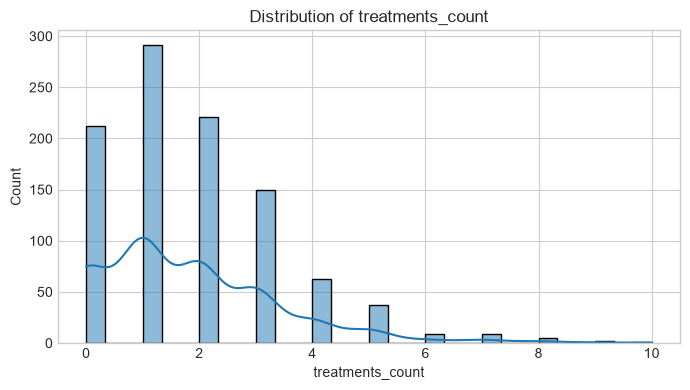

In [35]:
num_plot_cols = [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "blood_sugar_mg_dl",
    "cholesterol_mg_dl",
    "bmi",
    "lab_tests_count",
    "treatments_count",
]
cols = [c for c in num_plot_cols if c in data.columns]

for col in cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=data, x=col, kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{col}_histogram.png", dpi=300)
    plt.show()


### 4.2 Numerical Feature Distributions across Risk Levels

The boxplots show that the risk groups differ in their clinical ranges, especially for age, blood sugar, cholesterol, and BMI. The groups overlap somewhat, which indicates that disease risk is a real multi-class problem rather than a simple threshold rule.


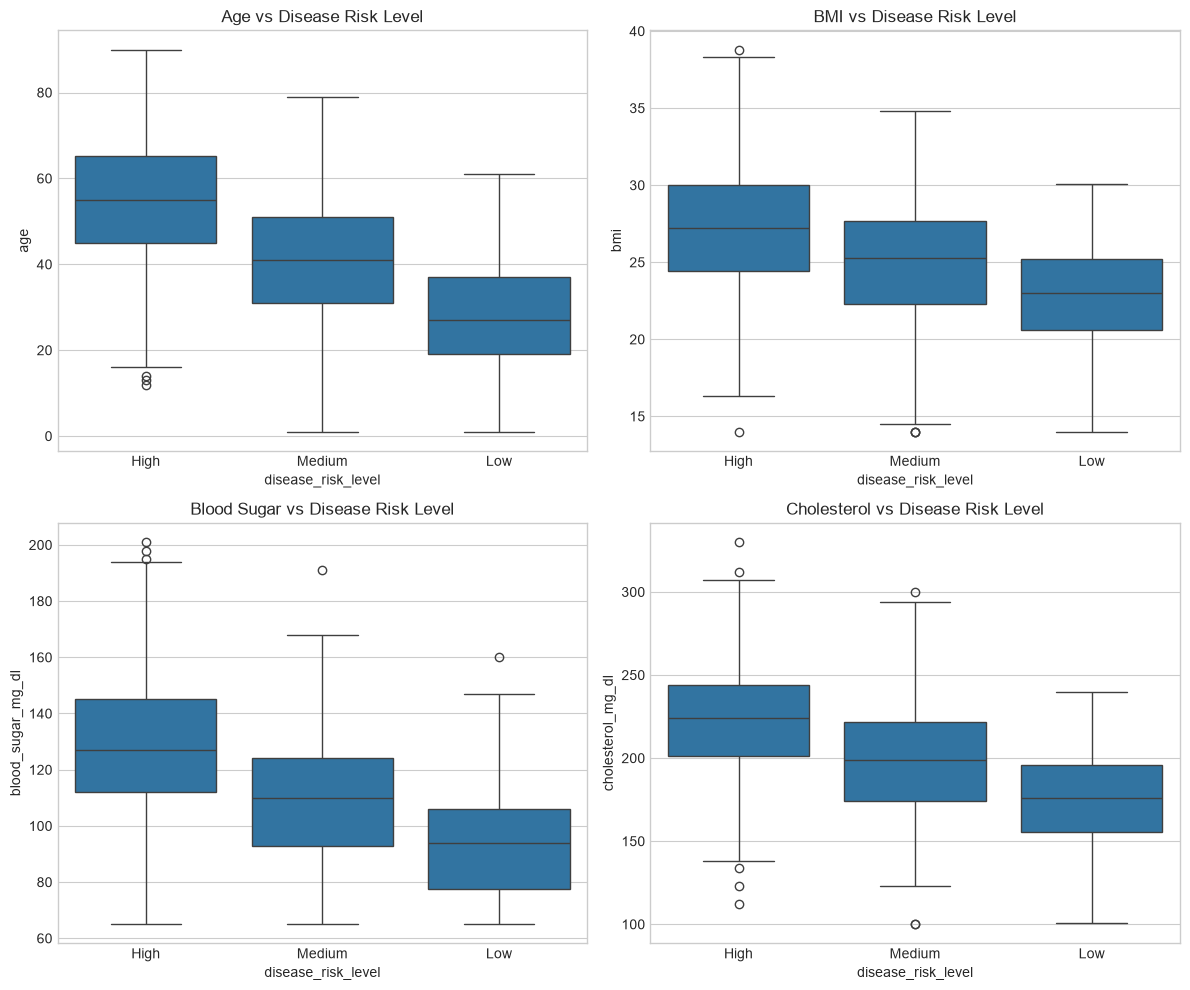

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cols = [
    ("age", "Age vs Disease Risk Level"),
    ("bmi", "BMI vs Disease Risk Level"),
    ("blood_sugar_mg_dl", "Blood Sugar vs Disease Risk Level"),
    ("cholesterol_mg_dl", "Cholesterol vs Disease Risk Level"),
]

for ax, (col, title) in zip(axes.flatten(), cols):
    if col in data.columns:
        sns.boxplot(data=data, x="disease_risk_level", y=col, ax=ax, order=None)
        ax.set_title(title)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "clinical_features_boxplot.png", dpi=300)
plt.show()


### 4.3 Scatter Plots & Additional Pattern Visualizations

The blood sugar versus cholesterol scatterplot shows a broad spread across the three risk levels, with higher-risk patients tending to appear in regions with more elevated clinical values. This supports using multiple features together instead of relying on one single measure.


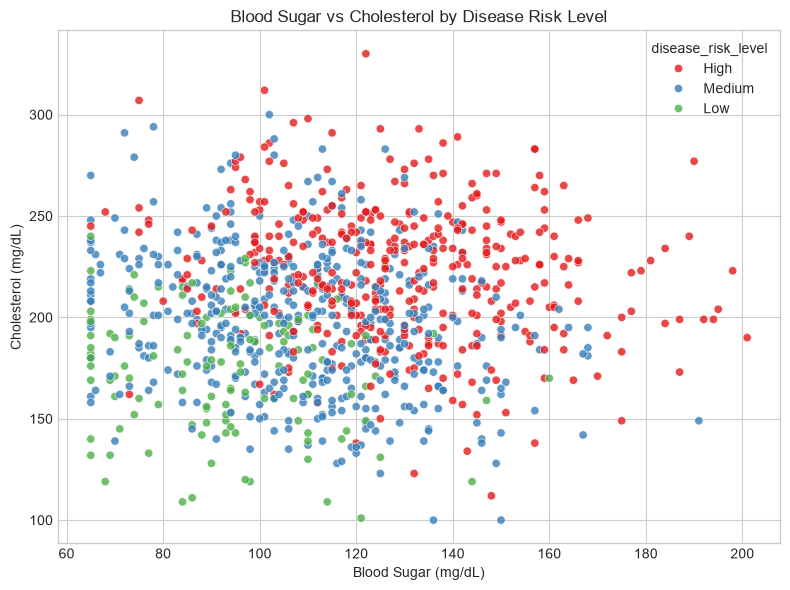

In [37]:
plt.figure(figsize=(8, 6))
if all(c in data.columns for c in ["blood_sugar_mg_dl", "cholesterol_mg_dl"]):
    sns.scatterplot(
        data=data,
        x="blood_sugar_mg_dl",
        y="cholesterol_mg_dl",
        hue="disease_risk_level",
        palette="Set1",
        alpha=0.8,
    )
    plt.title("Blood Sugar vs Cholesterol by Disease Risk Level")
    plt.xlabel("Blood Sugar (mg/dL)")
    plt.ylabel("Cholesterol (mg/dL)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "blood_sugar_vs_cholesterol_scatter.png", dpi=300)
    plt.show()
else:
    print("Required columns for scatter plot not present; skipping.")


### 4.4 Correlation Heatmap

The heatmap shows that the numerical features are not all strongly correlated. This is useful because it suggests that multiple clinically relevant variables contribute to the model rather than one dominant redundant variable.


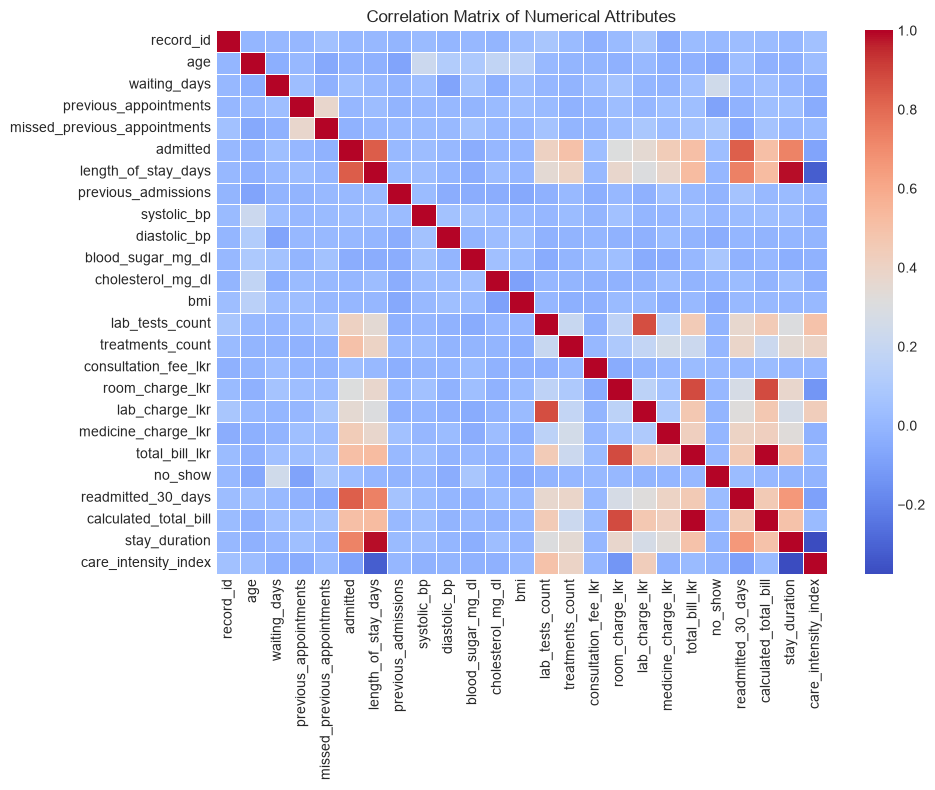

In [38]:
numeric_df = data.select_dtypes(include=[np.number]).copy()
exclude_cols = {"disease_risk_encoded"}
for c in list(exclude_cols):
    if c in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=c)

corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Attributes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=300)
plt.show()


Categorical columns available for simple analysis: ['gender', 'diagnosis', 'department', 'blood_group', 'room_type', 'payment_status', 'admitted']


disease_risk_level,High,Low,Medium
gender,,,
Female,41.082164,13.426854,45.490982
Male,38.922156,12.774451,48.303393


<Figure size 800x400 with 0 Axes>

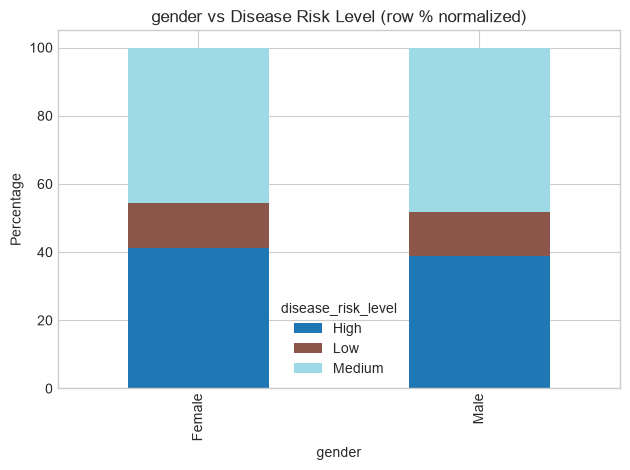

disease_risk_level,High,Low,Medium
diagnosis,,,
Asthma,39.130435,14.130435,46.739130
Back Pain,33.653846,18.269231,48.076923
Chest Pain,35.632184,10.344828,54.022989
Diabetes,60.824742,3.092784,36.082474
Fever,34.579439,22.429907,42.990654
Fracture,42.307692,12.500000,45.192308
Hypertension,32.584270,12.359551,55.056180
Kidney Infection,37.623762,14.851485,47.524752
Migraine,39.423077,10.576923,50.000000


<Figure size 800x400 with 0 Axes>

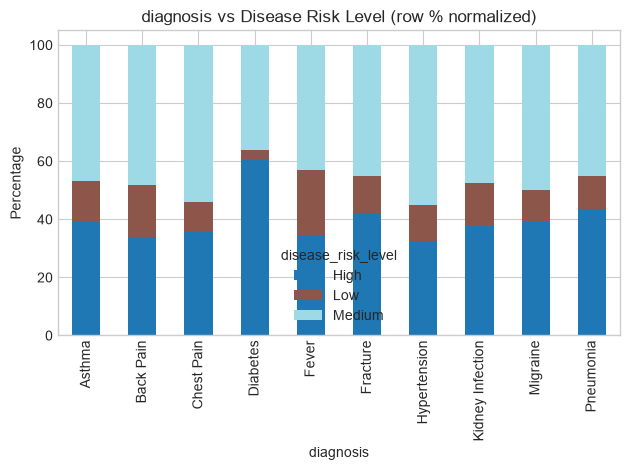

disease_risk_level,High,Low,Medium
department,,,
Cardiology,43.037975,7.594937,49.367089
General Medicine,44.654088,11.949686,43.396226
Laboratory Services,43.103448,13.793103,43.103448
Neurology,36.486486,13.513514,50.000000
Orthopedics,31.205674,21.276596,47.517730
Pediatrics,43.478261,10.869565,45.652174
Radiology,37.857143,13.571429,48.571429


<Figure size 800x400 with 0 Axes>

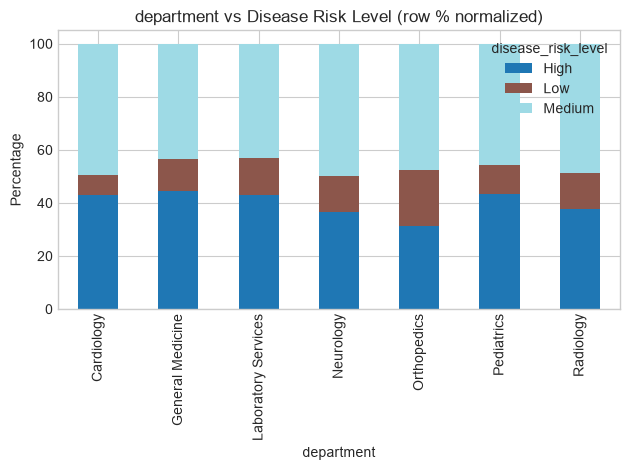

disease_risk_level,High,Low,Medium
blood_group,,,
A+,40.000000,12.500000,47.500000
A-,41.481481,10.370370,48.148148
AB+,45.081967,17.213115,37.704918
AB-,32.352941,15.441176,52.205882
B+,35.606061,15.151515,49.242424
B-,42.857143,12.500000,44.642857
O+,43.518519,7.407407,49.074074
O-,40.740741,13.333333,45.925926


<Figure size 800x400 with 0 Axes>

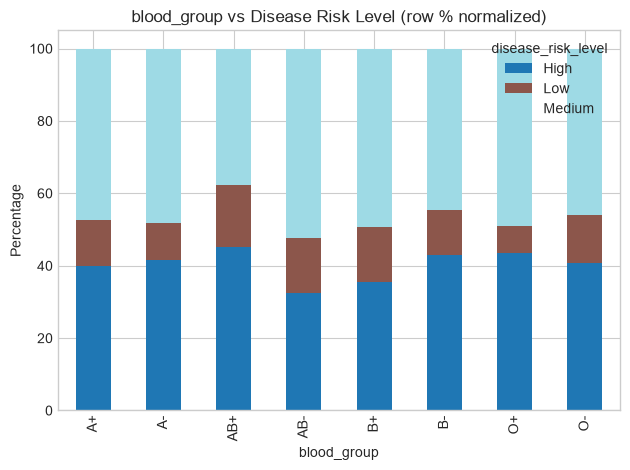

disease_risk_level,High,Low,Medium
room_type,,,
General Ward,53.846154,15.384615,30.769231
ICU,33.333333,11.111111,55.555556
None,39.514349,13.024283,47.461369
Private Room,33.333333,12.121212,54.545455


<Figure size 800x400 with 0 Axes>

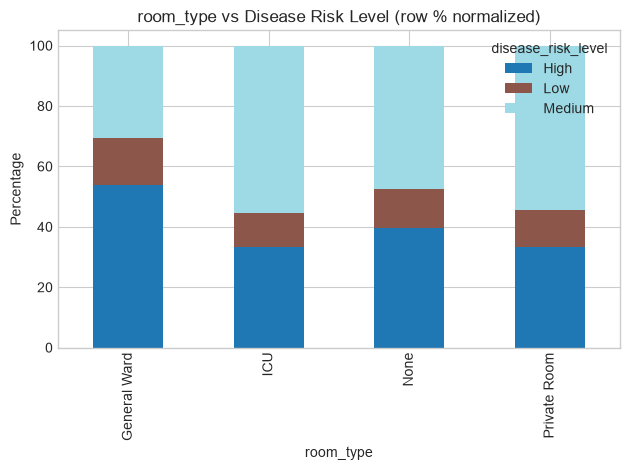

disease_risk_level,High,Low,Medium
payment_status,,,
Paid,38.922156,13.173653,47.904192
Partially Paid,40.833333,14.166667,45.000000
Unpaid,42.924528,12.264151,44.811321


<Figure size 800x400 with 0 Axes>

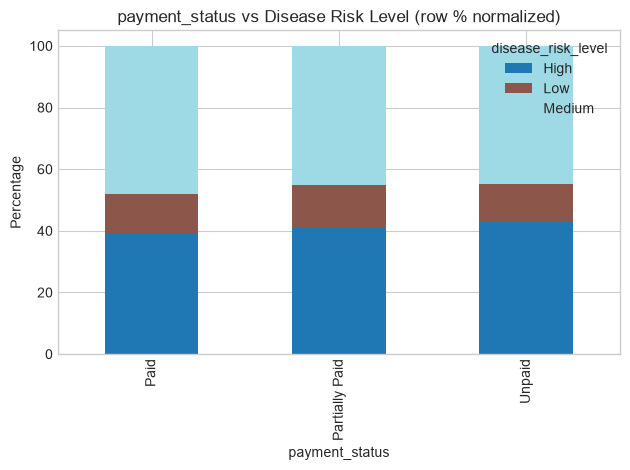

disease_risk_level,High,Low,Medium
admitted,,,
0,39.850746,12.835821,47.313433
1,40.303030,13.636364,46.060606


<Figure size 800x400 with 0 Axes>

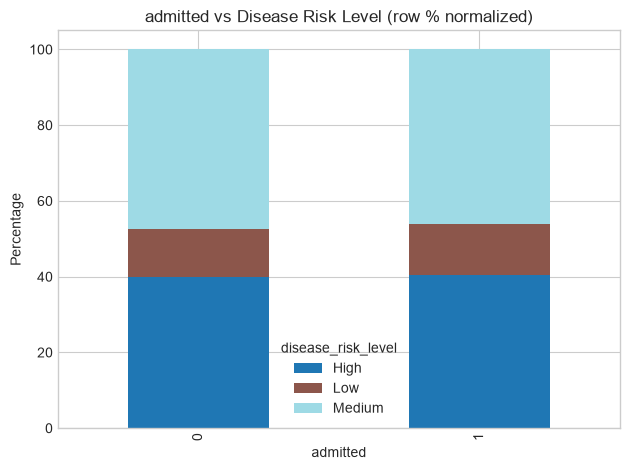

In [39]:
cat_candidates = ["gender", "diagnosis", "department", "blood_group", "room_type", "payment_status", "admitted"]
available = [c for c in cat_candidates if c in data.columns]
print("Categorical columns available for simple analysis:", available)

for c in available:
    ct = pd.crosstab(data[c], data["disease_risk_level"], normalize="index") * 100
    display(ct.head(10))
    plt.figure(figsize=(8, 4))
    ct.plot(kind="bar", stacked=True, colormap="tab20", legend=True)
    plt.title(f"{c} vs Disease Risk Level (row % normalized)")
    plt.ylabel("Percentage")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{c}_vs_disease_risk_level.png", dpi=300)
    plt.show()


### EDA Interpretation

The dataset is moderately imbalanced, with Medium risk as the most common category and Low risk as the least common. The numerical plots suggest that age, blood pressure, blood sugar, cholesterol, and BMI differ across the risk groups, while the scatterplot indicates that high clinical measurements often align with higher disease risk. Extreme values are kept unless there is clear evidence they are erroneous, because clinically plausible outliers can still reflect real patient conditions.


## Task 05: Machine Learning Model Development

The train-test split is performed before preprocessing to avoid leakage. A preprocessing pipeline is then applied to numeric and categorical variables so the selected models are trained on properly prepared features.


### 5.1 Train-Test Split & Preprocessing Pipeline Setup

The dataset is split stratified by the target label and a column transformer is used to impute missing values, scale numeric features, and one-hot encode categorical values. This keeps the modelling workflow simple, reproducible, and suitable for undergraduate explanation.


In [40]:
TARGET = "disease_risk_level"

if TARGET not in data.columns:
    raise KeyError(f"Target column '{TARGET}' not found in dataset")

missing_target = data[TARGET].isnull().sum()
print(f"Missing target labels: {missing_target}")
if missing_target > 0:
    print(f"Removing {missing_target} rows with missing target labels")
    data = data[data[TARGET].notna()].copy()

dup_count = data.duplicated().sum()
print(f"Duplicate rows in dataset: {dup_count}")
if dup_count > 0:
    data = data.drop_duplicates().copy()
    print(f"Duplicates removed. New row count: {data.shape[0]}")

if "appointment_date" in data.columns:
    data["appointment_date"] = pd.to_datetime(data["appointment_date"], errors="coerce")
    data["appointment_year"] = data["appointment_date"].dt.year
    data["appointment_month"] = data["appointment_date"].dt.month
    data["appointment_day"] = data["appointment_date"].dt.day
    data["appointment_dayofweek"] = data["appointment_date"].dt.dayofweek
    data["appointment_is_weekend"] = data["appointment_dayofweek"].isin([5, 6]).astype(int)
    print("Appointment date features created")

identifier_cols = [c for c in ["record_id", "patient_id"] if c in data.columns]
if identifier_cols:
    print("Identifier columns to remove from modelling:", identifier_cols)

leakage_cols = [c for c in ["no_show", "readmitted_30_days"] if c in data.columns]
if leakage_cols:
    print("Columns excluded from predictors due to potential leakage:", leakage_cols)

numeric_cols_all = data.select_dtypes(include=[np.number]).columns.tolist()
exclude_for_outliers = set(identifier_cols + ["disease_risk_encoded"])
numeric_cols = [c for c in numeric_cols_all if c not in exclude_for_outliers]

outlier_summary = []
for col in numeric_cols:
    try:
        col_series = data[col].dropna()
        q1 = col_series.quantile(0.25)
        q3 = col_series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = ((col_series < lower) | (col_series > upper)).sum()
        outlier_summary.append({
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(outlier_count),
        })
    except Exception:
        continue

outlier_df = pd.DataFrame(outlier_summary).sort_values(by="outlier_count", ascending=False)
print("Outlier summary (top rows):")
display(outlier_df.head(10))

model_drop_cols = [TARGET] + identifier_cols + leakage_cols
if "appointment_date" in data.columns:
    model_drop_cols.append("appointment_date")

X = data.drop(columns=[col for col in model_drop_cols if col in data.columns])
y = data[TARGET].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Label encoder classes:", list(label_encoder.classes_))

joblib.dump(label_encoder, MODELS_DIR / "disease_risk_label_encoder.joblib")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded,
)

print(f"Train Size: {X_train.shape[0]} | Test Size: {X_test.shape[0]}")

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", ohe),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Preprocessor created successfully.")


Missing target labels: 0
Duplicate rows in dataset: 0
Appointment date features created
Identifier columns to remove from modelling: ['record_id', 'patient_id']
Columns excluded from predictors due to potential leakage: ['no_show', 'readmitted_30_days']
Outlier summary (top rows):


,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
22,stay_duration,1.0,2.0,1.0,-0.50,3.50,149
15,room_charge_lkr,0.0,0.0,0.0,0.00,0.00,94
16,lab_charge_lkr,2400.0,6300.0,3900.0,-3450.00,12150.00,61
6,previous_admissions,0.0,1.0,1.0,-1.50,2.50,60
18,total_bill_lkr,11018.0,20870.0,9852.0,-3760.00,35648.00,59
21,calculated_total_bill,11018.0,20870.0,9852.0,-3760.00,35648.00,59
5,length_of_stay_days,0.0,2.0,2.0,-3.00,5.00,48
23,care_intensity_index,1.5,4.0,2.5,-2.25,7.75,23
12,lab_tests_count,1.0,3.0,2.0,-2.00,6.00,23
3,missed_previous_appointments,0.0,1.0,1.0,-1.50,2.50,17


Label encoder classes: ['High', 'Low', 'Medium']
Train Size: 800 | Test Size: 200
Numerical features: 27
Categorical features: 8
Preprocessor created successfully.


In [41]:
model_data = X.copy()
model_data[TARGET] = y.values
processed_save_path = PROCESSED_DATA_DIR / "smartcare_disease_risk_model_data.csv"
model_data.to_csv(processed_save_path, index=False)
print("Saved processed model-ready data to", processed_save_path)


Saved processed model-ready data to ..\data\processed\smartcare_disease_risk_model_data.csv


### 5.2 Model Training & Hyperparameter Optimization

Four models are trained and compared: Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine. The Random Forest is tuned using only the training data, with 5-fold stratified cross-validation and macro F1 as the tuning score.


In [42]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Support Vector Machine": SVC(probability=True, random_state=42),
}

trained_pipelines = {}
cv_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    trained_pipelines[name] = pipe.fit(X_train, y_train)
    cv_results[name] = {
        "cv_f1_macro_mean": scores.mean(),
        "cv_f1_macro_std": scores.std(),
    }
    print(f"{name} - CV F1 Macro: {scores.mean():.4f} (+/- {scores.std():.4f})")

rf_param_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
}
rf_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))])
rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=0)
print("Starting GridSearchCV for Random Forest (this may take a while)...")
rf_grid.fit(X_train, y_train)
print("Random Forest best params:", rf_grid.best_params_)
print("Random Forest best CV F1 Macro:", rf_grid.best_score_)

trained_pipelines["Random Forest (Tuned)"] = rf_grid.best_estimator_
cv_results["Random Forest (Tuned)"] = {
    "cv_f1_macro_mean": rf_grid.best_score_,
    "cv_f1_macro_std": None,
}


Logistic Regression - CV F1 Macro: 0.9120 (+/- 0.0329)
Decision Tree - CV F1 Macro: 0.6442 (+/- 0.0315)
Random Forest - CV F1 Macro: 0.6300 (+/- 0.0326)
Support Vector Machine - CV F1 Macro: 0.7537 (+/- 0.0457)
Starting GridSearchCV for Random Forest (this may take a while)...
Random Forest best params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Random Forest best CV F1 Macro: 0.6369557550452244


## Task 06: Model Evaluation

The models are evaluated on the held-out test set using accuracy, macro precision, macro recall, macro F1, and a confusion matrix. Macro F1 is important because the classes are not perfectly balanced and a model that performs well only on the majority class is not necessarily the best classifier.


### 6.1 Performance Evaluation Metrics & Comparison Table

The model comparison table shows each model’s performance on the test set. The best model is selected using the highest macro F1 rather than by accuracy alone, because macro F1 better reflects performance across all three disease-risk classes.


Saved model comparison to ..\outputs\metrics\model_comparison.csv


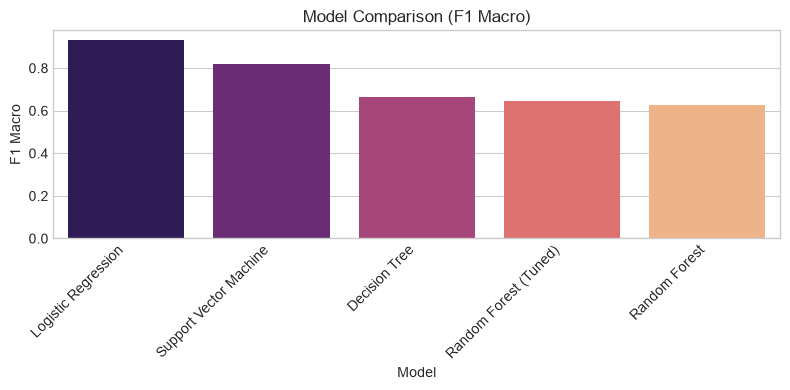

,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,Precision_Weighted,Recall_Weighted,F1_Weighted,CV_F1_Macro_Mean,CV_F1_Macro_Std
Logistic Regression,0.945,0.939728,0.922034,0.930321,0.945123,0.945,0.944753,0.911991,0.032862
Support Vector Machine,0.885,0.926953,0.784875,0.820686,0.899731,0.885,0.876444,0.753717,0.045655
Decision Tree,0.685,0.667324,0.667096,0.666193,0.687917,0.685,0.685233,0.644186,0.031503
Random Forest (Tuned),0.785,0.876108,0.633552,0.643719,0.830385,0.785,0.756843,0.636956,NaN
Random Forest,0.785,0.886826,0.623036,0.626193,0.842613,0.785,0.752310,0.630012,0.032645


In [43]:
results = {}
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

    prec_w = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec_w = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1_w = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results[name] = {
        "Accuracy": acc,
        "Precision_Macro": prec_macro,
        "Recall_Macro": rec_macro,
        "F1_Macro": f1_macro,
        "Precision_Weighted": prec_w,
        "Recall_Weighted": rec_w,
        "F1_Weighted": f1_w,
    }

results_df = pd.DataFrame(results).T
results_df["CV_F1_Macro_Mean"] = results_df.index.map(lambda n: cv_results.get(n, {}).get("cv_f1_macro_mean"))
results_df["CV_F1_Macro_Std"] = results_df.index.map(lambda n: cv_results.get(n, {}).get("cv_f1_macro_std"))
results_df = results_df.sort_values(by="F1_Macro", ascending=False)

results_df.to_csv(METRICS_DIR / "model_comparison.csv")
print("Saved model comparison to", METRICS_DIR / "model_comparison.csv")

plt.figure(figsize=(8, 4))
sns.barplot(x=results_df.index, y="F1_Macro", data=results_df.reset_index(), palette="magma")
plt.title("Model Comparison (F1 Macro)")
plt.ylabel("F1 Macro")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_f1_macro.png", dpi=300)
plt.show()

display(results_df)


### 6.2 Best Model Selection, Detailed Classification Report & Confusion Matrix

The selected model is the one with the strongest macro F1 on the test set. The detailed classification report and confusion matrix help explain which classes are easier or harder for the model to identify.


Best Performing Model: Logistic Regression
Detailed Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.96      0.97        80
         Low       0.92      0.85      0.88        26
      Medium       0.93      0.96      0.94        94

    accuracy                           0.94       200
   macro avg       0.94      0.92      0.93       200
weighted avg       0.95      0.94      0.94       200

Model successfully serialized to ..\models\best_disease_risk_model.joblib


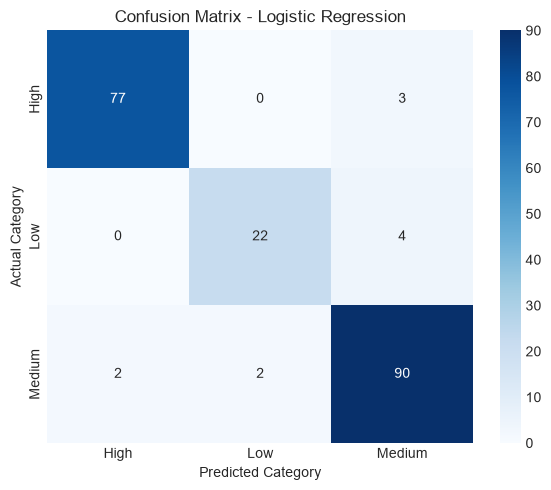

In [46]:
best_model_name = results_df["F1_Macro"].idxmax()
best_pipeline = trained_pipelines[best_model_name]
print(f"Best Performing Model: {best_model_name}")

y_pred_best = best_pipeline.predict(X_test)
class_labels = list(label_encoder.classes_)
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=class_labels, zero_division=0))

joblib.dump(best_pipeline, MODELS_DIR / "best_disease_risk_model.joblib")
print(f"Model successfully serialized to {MODELS_DIR / 'best_disease_risk_model.joblib'}")

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.ylabel("Actual Category")
plt.xlabel("Predicted Category")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_model_confusion_matrix.png", dpi=300)
plt.show()


## Task 07: Explainable AI (XAI) Analysis

Permutation feature importance is used as the explainable AI method for the selected best model. It measures how much the model’s macro F1 changes when each feature is randomly shuffled, which makes the variable importance easy to interpret.


### 7.1 Permutation Feature Importance Analysis

The permutation importance plot shows which features most strongly affect the disease-risk predictions. This approach provides a transparent, model-agnostic explanation while keeping the notebook readable and practical for coursework presentation.


Computing permutation importance on the test set...
Saved permutation importance to ..\outputs\metrics\feature_importance.csv


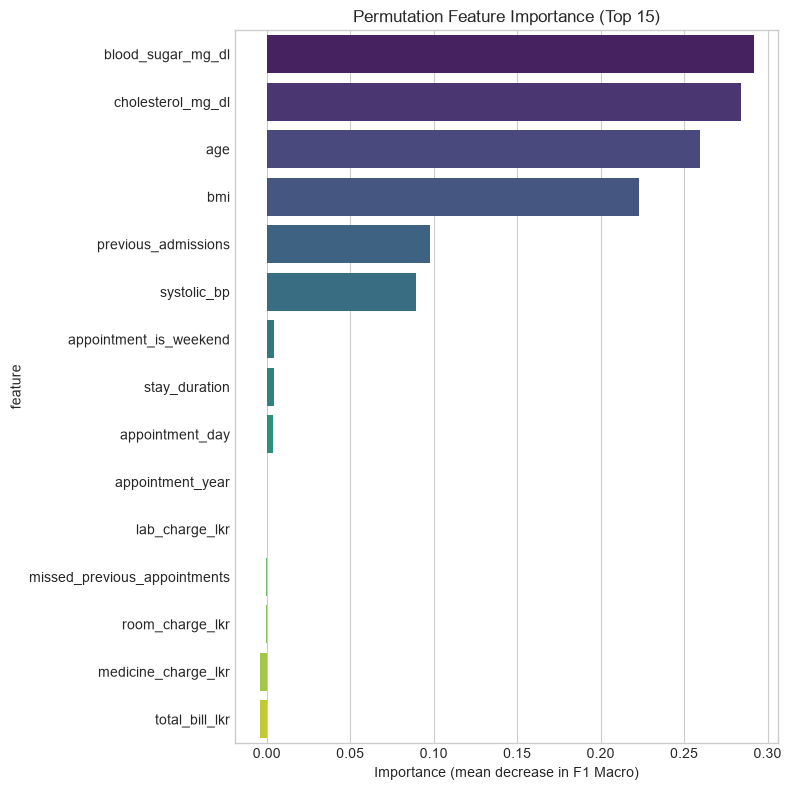

Best model does not expose feature_importances_; skipping tree importances.


In [47]:
print("Computing permutation importance on the test set...")
perm_res = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_res.importances_mean,
    "importance_std": perm_res.importances_std,
}).sort_values(by="importance_mean", ascending=False)

perm_df.to_csv(METRICS_DIR / "feature_importance.csv", index=False)
print("Saved permutation importance to", METRICS_DIR / "feature_importance.csv")

top_n = 15
plt.figure(figsize=(8, min(0.4 * top_n + 2, 12)))
sns.barplot(x="importance_mean", y="feature", data=perm_df.head(top_n), palette="viridis")
plt.title(f"Permutation Feature Importance (Top {top_n})")
plt.xlabel("Importance (mean decrease in F1 Macro)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "permutation_feature_importance.png", dpi=300)
plt.show()

clf = best_pipeline.named_steps["classifier"]
pre = best_pipeline.named_steps["preprocessor"]
if hasattr(clf, "feature_importances_"):
    try:
        transformed_names = pre.get_feature_names_out()
        tree_importances = pd.Series(clf.feature_importances_, index=transformed_names).sort_values(ascending=False)
        plt.figure(figsize=(8, min(0.4 * 15 + 2, 12)))
        tree_importances.head(15).plot(kind="barh", color="teal")
        plt.title("Model Built-in Feature Importances (Top 15)")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "tree_feature_importance.png", dpi=300)
        plt.show()
    except Exception as e:
        print("Could not compute tree feature importances:", e)
else:
    print("Best model does not expose feature_importances_; skipping tree importances.")


### Ethical Implications

The model should be treated as a decision-support tool rather than a replacement for a healthcare professional. Patient privacy, possible bias, class imbalance, and incorrect predictions must be considered when interpreting the results. Human supervision remains necessary, and the predictions should be used to support clinical review rather than to make independent medical decisions.
